In [ ]:
import numpy as np
import cv2
import hdbscan
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
import matplotlib
import random
import os
import json
import torch 
import h5py
import glob
from numpy import linalg as LA

random.seed(10)

# Exploration

In [1]:
import os
import torch
from deeplsd.models.deeplsd_inference import DeepLSD
from ground_truth.main_process import process_image

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conf = {'detect_lines': True, 'line_detection_params': {'merge': False, 'filtering': True, 'grad_thresh': 3}}
ckpt = torch.load('../weights/deeplsd_md.tar', map_location='cpu', weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net = net.to(device).eval()


Start : 1744811247.254529


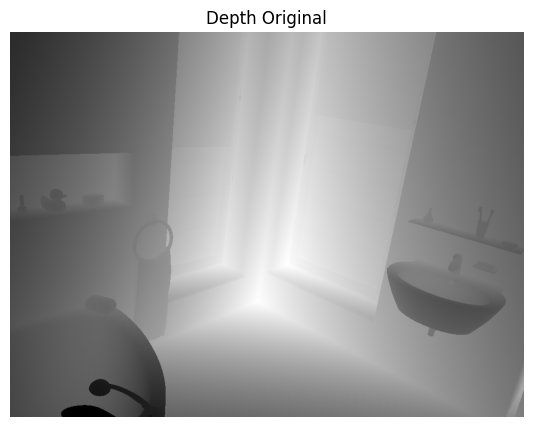

???


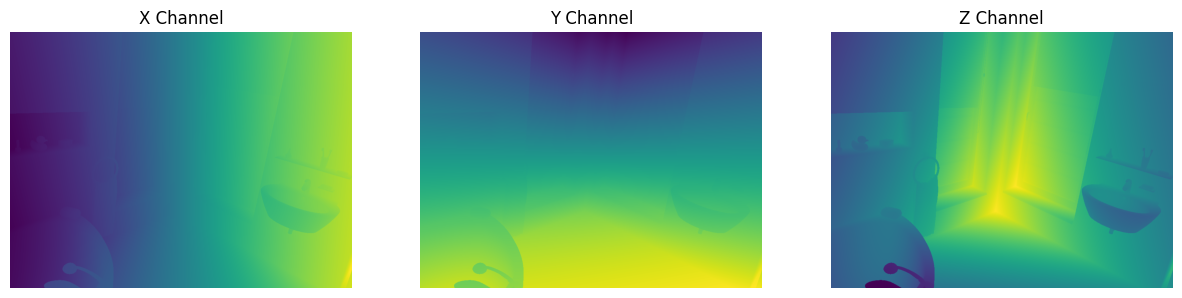

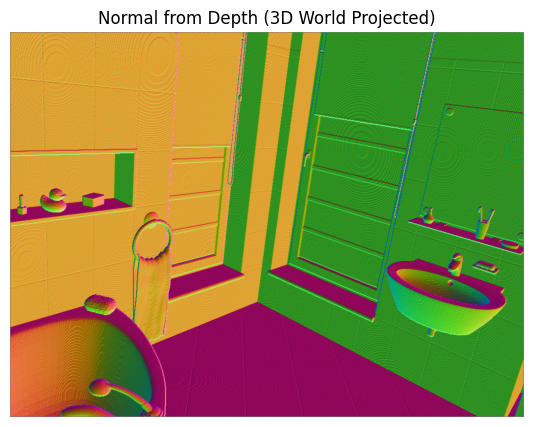

[04/16/2025 15:47:27 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


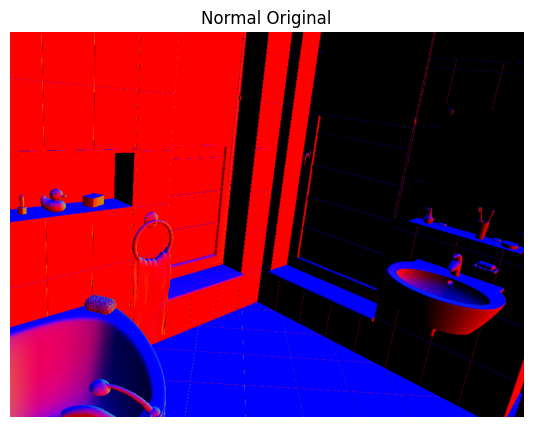

Time to get depth and calculate normal map and wd : 0.7807450294494629
Time for DeepLSD : 7.124626874923706
Time to calculate sobels : 0.07188916206359863
Time for structural vs textural : 0.08611679077148438
Time for line splitting : 0.12295293807983398
Time to get CC : 0.00110626220703125
Number of connected components (including background): 35
Cluster 1: valid plane with mean error 0.0009.
Cluster 2: valid plane with mean error 0.0089.
Cluster 3: valid plane with mean error 0.0004.
Cluster 4: valid plane with mean error 0.0004.
Cluster 5: valid plane with mean error 0.0066.
Cluster 6: valid plane with mean error 0.0004.
Cluster 7: valid plane with mean error 0.0071.
Cluster 8: valid plane with mean error 0.0005.
Cluster 9: valid plane with mean error 0.0016.
Cluster 10: valid plane with mean error 0.0004.
Cluster 11: valid plane with mean error 0.0052.
Cluster 12: valid plane with mean error 0.0006.
Cluster 13: valid plane with mean error 0.0002.
Cluster 14: valid plane with mean e

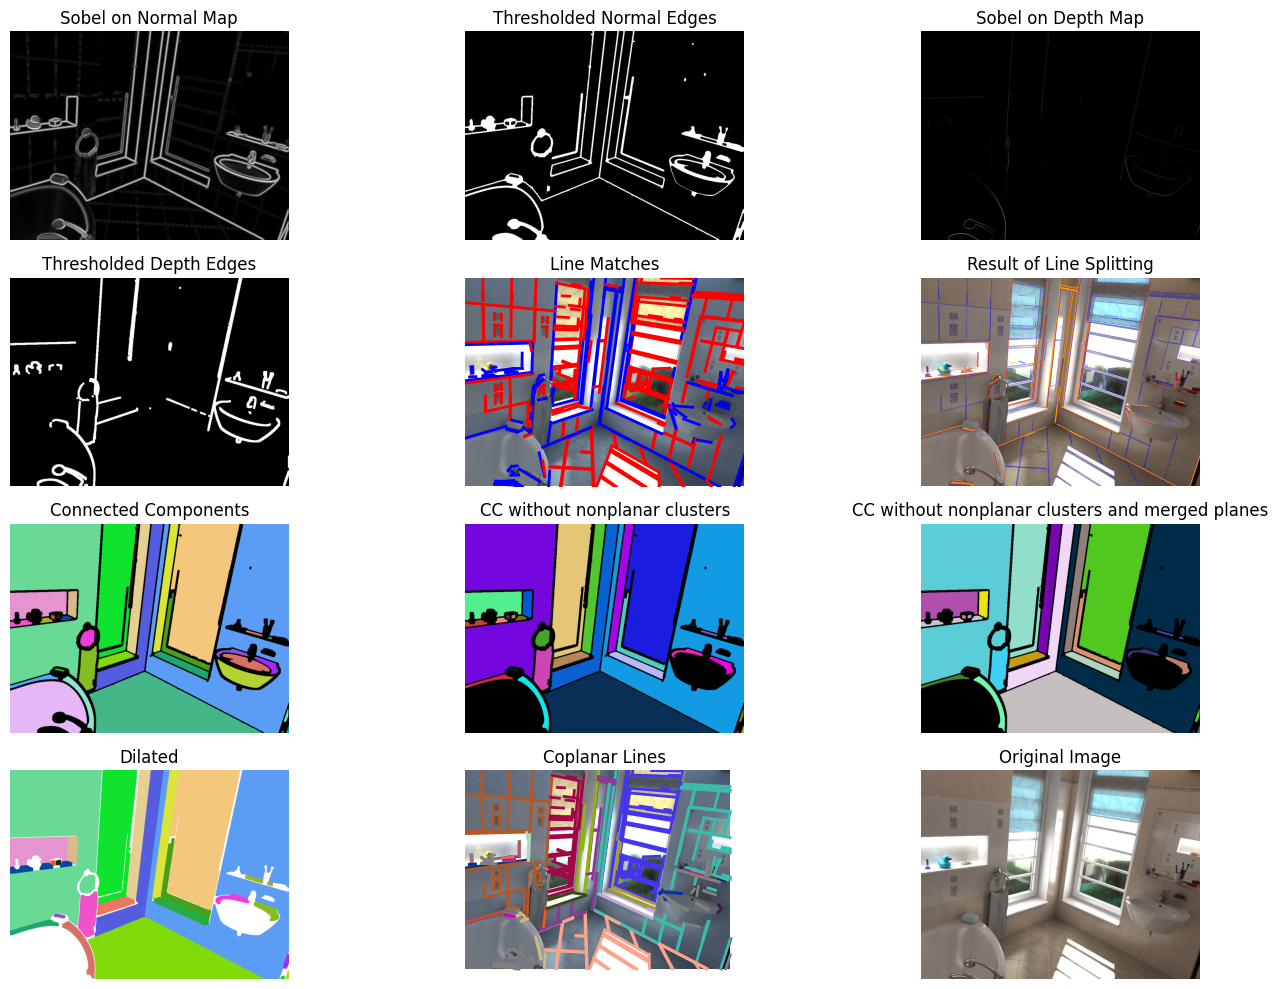

Start : 1744811258.474347


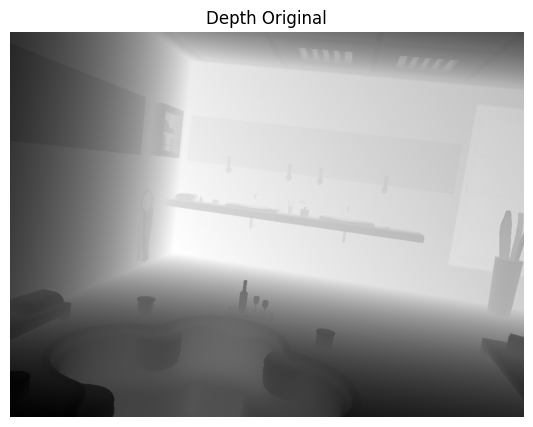

???


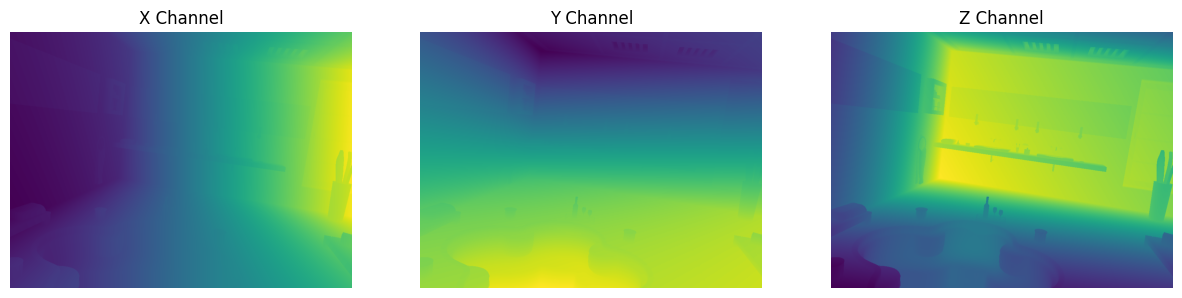

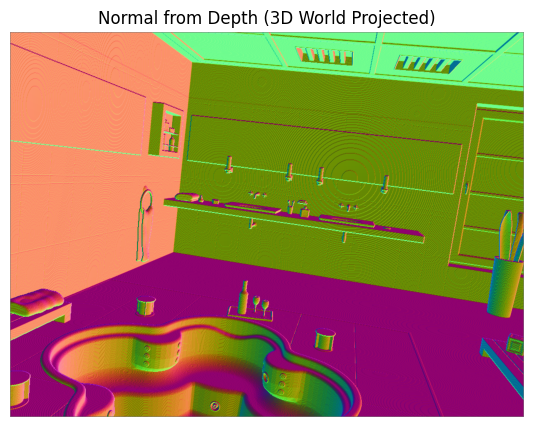

[04/16/2025 15:47:39 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


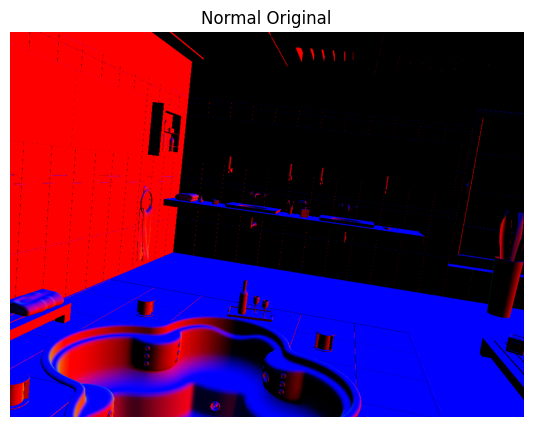

Time to get depth and calculate normal map and wd : 0.8675587177276611
Time for DeepLSD : 6.722738265991211
Time to calculate sobels : 0.06951498985290527
Time for structural vs textural : 0.06421208381652832
Time for line splitting : 0.17122364044189453
Time to get CC : 0.0008749961853027344
Number of connected components (including background): 83
Cluster 1: valid plane with mean error 0.0013.
Cluster 2: valid plane with mean error 0.0004.
Cluster 3: valid plane with mean error 0.0005.
Cluster 4: valid plane with mean error 0.0014.
Cluster 5: valid plane with mean error 0.0003.
Cluster 6: valid plane with mean error 0.0011.
Cluster 7: valid plane with mean error 0.0004.
Cluster 8: valid plane with mean error 0.0020.
Cluster 9: valid plane with mean error 0.0006.
Cluster 12: valid plane with mean error 0.0010.
Cluster 13: valid plane with mean error 0.0052.
Cluster 14: valid plane with mean error 0.0012.
Cluster 19: valid plane with mean error 0.0017.
Cluster 20: valid plane with mean

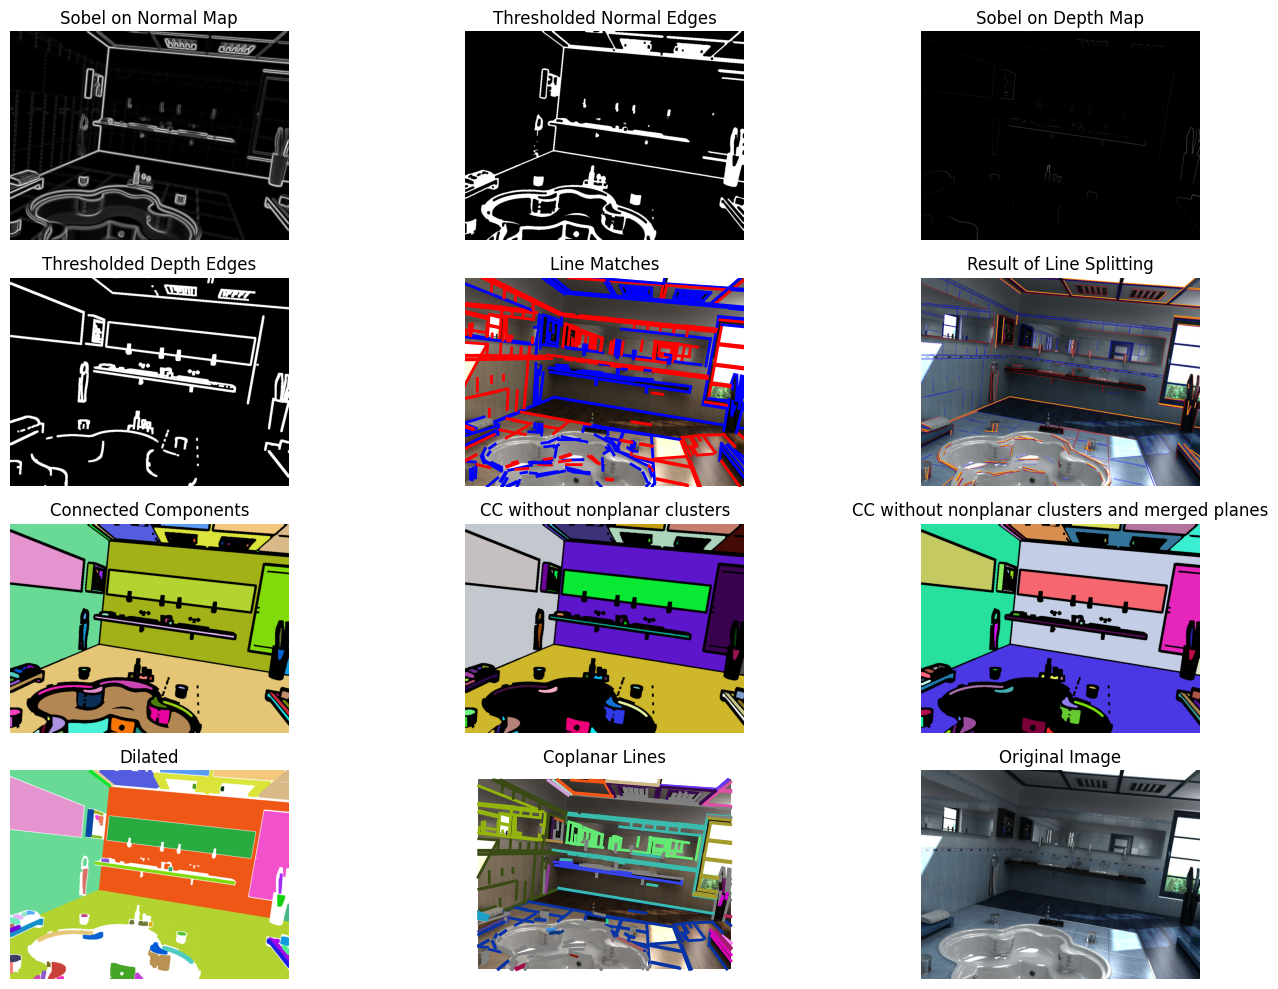

Start : 1744811270.41086


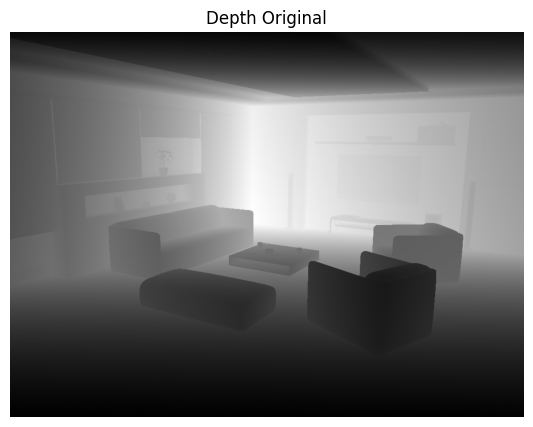

???


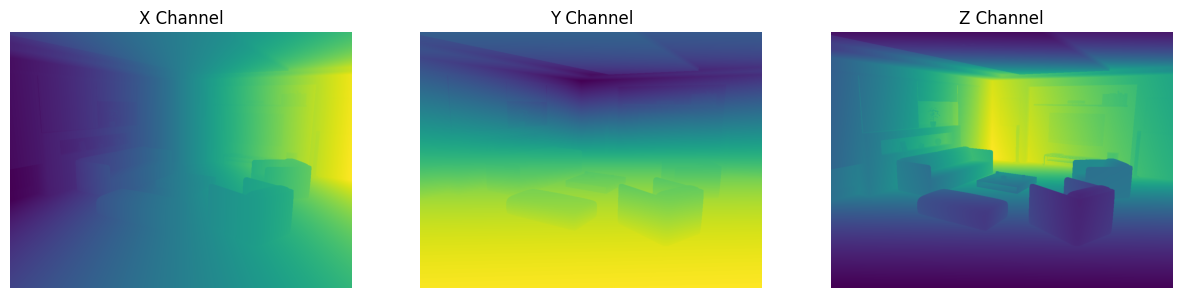

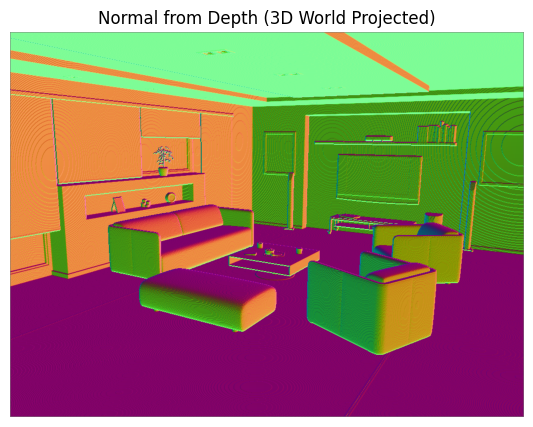

[04/16/2025 15:47:51 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


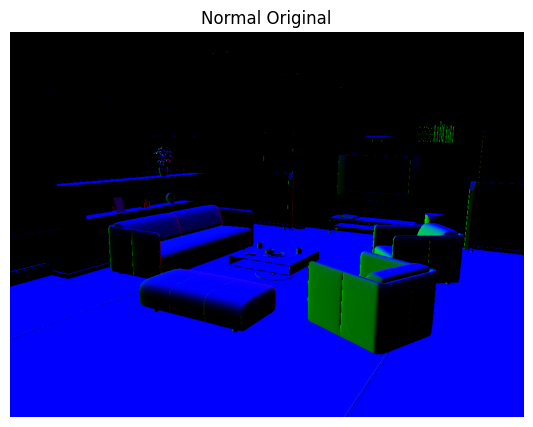

Time to get depth and calculate normal map and wd : 0.767970085144043
Time for DeepLSD : 6.541614770889282
Time to calculate sobels : 0.06974506378173828
Time for structural vs textural : 0.05889105796813965
Time for line splitting : 0.10403990745544434
Time to get CC : 0.0012209415435791016
Number of connected components (including background): 56
Cluster 1: valid plane with mean error 0.0002.
Cluster 2: valid plane with mean error 0.0016.
Cluster 3: valid plane with mean error 0.0002.
Cluster 4: valid plane with mean error 0.0002.
Cluster 5: valid plane with mean error 0.0015.
Cluster 6: valid plane with mean error 0.0006.
Cluster 7: valid plane with mean error 0.0054.
Cluster 9: valid plane with mean error 0.0002.
Cluster 10: valid plane with mean error 0.0002.
Cluster 11: valid plane with mean error 0.0053.
Cluster 12: valid plane with mean error 0.0015.
Cluster 13: valid plane with mean error 0.0026.
Cluster 14: valid plane with mean error 0.0078.
Cluster 15: valid plane with mean

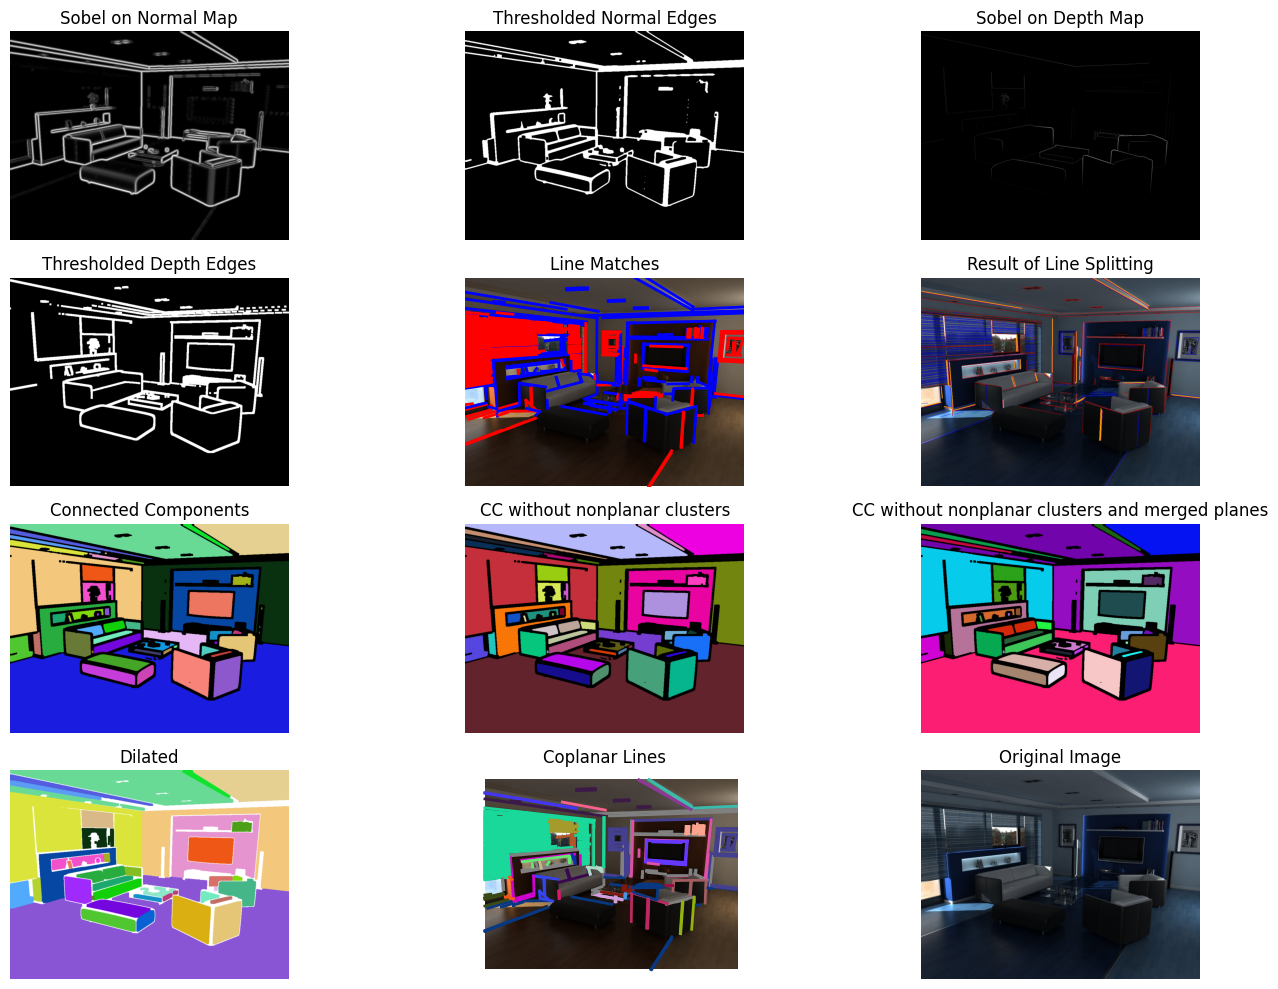

Start : 1744811281.4090939


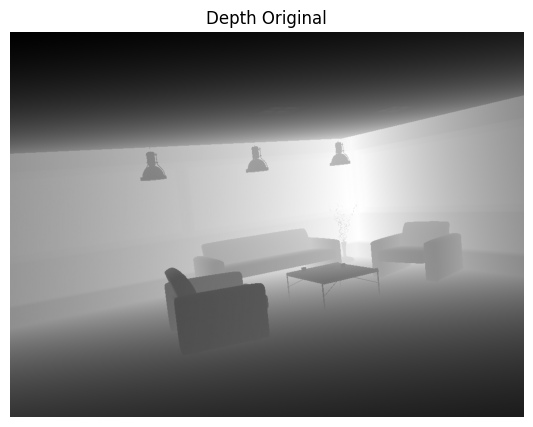

???


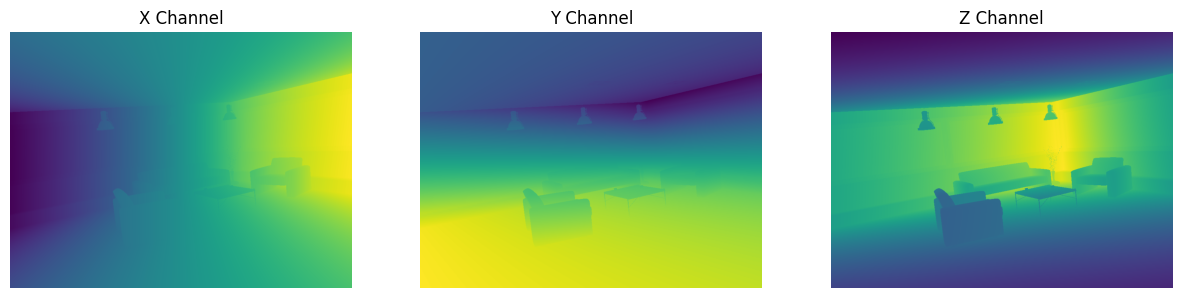

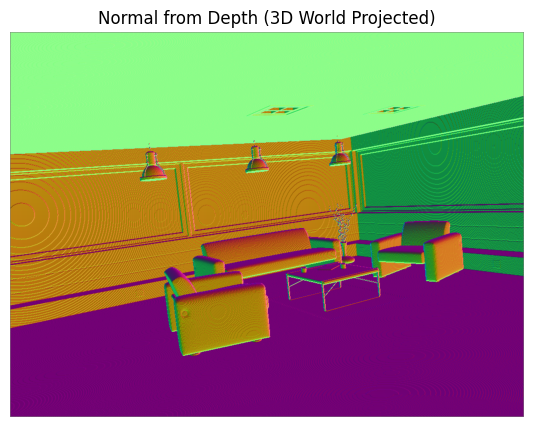

[04/16/2025 15:48:02 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


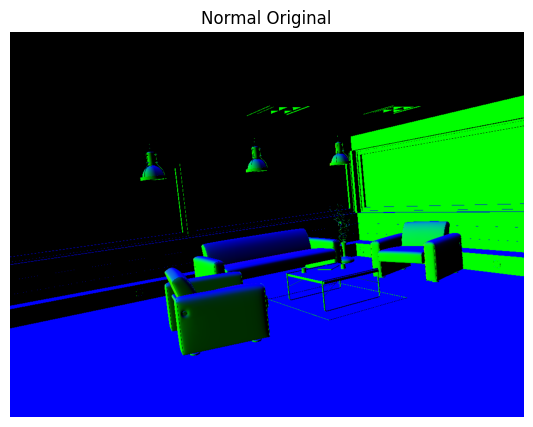

Time to get depth and calculate normal map and wd : 0.8185820579528809


KeyboardInterrupt: 

In [3]:
frame_str = "0001"
desired_images = [
    "ai_001_001",
    # "ai_001_004",
    # "ai_001_005",
    # "ai_001_006",
    "ai_001_007",
    "ai_001_008",
    "ai_001_009",
    "ai_002_001",

    #"DSC_0442",
    #"DSC_0455",
    #"DSC_0239",
    #"DSC_0249",
]

#moge = MoGeModel.from_pretrained("Ruicheng/moge-vitl").to(device)

# Process, plot, and save JSON data for each image.
for image_id in desired_images:
    #composite_after, pred_lines, img, normals, world_coordinates, valid_mask, line_info, scores, isstruct, original_lines
    # Load the model from huggingface hub (or load from local).
    image_dir = os.path.join("data", image_id)
    composite_after, pred_lines, img, normals, world_coordinates, valid_mask, line_info, scores, isstruct, original_lines = process_image(
        image_dir, image_id, frame_str, net, device,
        depth_thresh=50, normal_thresh=1.5 * 1e7,
        dataset="hypersim"
        #moge_model = moge
    )
    